# 웹사이트 크롤링

In [ ]:
!pip install jupyter
!pip install requests beautifulsoup4
!pip install kiwipiepy
!pip install gensim
!pip install sentence-transformers
!pip install matplotlib
!pip install scikit-learn
!pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 46.8 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=f29b9ba3d50ccfec21dc73d8e46f9345ea6814ce5777c8195217fda0a455169f
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.6 MB/s eta 0:00:00


In [ ]:
import requests
from bs4 import BeautifulSoup
import urllib.request
import json
import time
import pandas as pd

In [ ]:
# 1. 대상 URL
url = "https://n.news.naver.com/mnews/article/469/0000916179?sid=101"

# 2. HTTP 헤더 설정 (봇 차단 방지)
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/110.0.0.0 Safari/537.36"
}

try:
    # 3. 페이지 요청 및 파싱
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, "html.parser")

    # 4. 데이터 추출
    # 제목: media_end_head_title / 본문: dic_area
    title = soup.select_one(".media_end_head_title").get_text(strip=True)
    content = soup.select_one("#dic_area").get_text(strip=True)

    print(f"제목: {title}\n")
    print(f"본문: {content[:400]}...") # 너무 길어서 200자만 출력

except Exception as e:
    print(f"에러 발생: {e}")

제목: '탄소중립' 목표 기후금융에 10년간 790조 투입한다

본문: 금융위원장 주재 '생산적 금융 대전환 회의'2035 NDC 목표, 7년 420조→10년 790조투자기업 배출량 따지는 '금융 배출량'도 집적ESG 공시, 자산 30조 원 이상 상장사 의무화게티이미지뱅크정부가 정책금융기관을 통해 10년간 790조 원 규모의 대규모 기후금융을 투입한다. 2035년 온실가스 배출량을 2018년의 53~61% 배출하는 ‘2035 국가 온실가스 감축목표(NDC)'를 뒷받침하기 위해서다. 상장사의 환경·사회·지배구조(ESG) 관련 공시도 2028년부터 단계적으로 시행하기로 하고 '공시 로드맵' 초안을 공개했다.금융위원회는 25일 이억원 금융위원장 주재로 '생산적 금융 대전환 회의'를 열고 이 같은 내용의 기후금융 활성화 방안과 ESG 공시기준을 논의했다.우선 금융위는 당초 2024년부...


# 뉴스 API 활용

In [ ]:
# 1. 인증 정보
client_id = "lpO819RbYMcgr7QjUk3K"
client_secret = "Q6C33JvwJ4"

# 2. 검색 설정
encText = urllib.parse.quote("기후변화")
total_to_collect = 300   # 목표 수집 개수
display_count = 100      # 한 번에 가져올 개수 (최대값)

all_news = []

print(f"'{encText}' 검색어에 대한 데이터 수집을 시작합니다...")

# 3. 반복문을 이용한 호출 (1부터 1000까지 100씩 증가)
for start_index in range(1, total_to_collect + 1, display_count):
    url = f"https://openapi.naver.com/v1/search/news.json?query={encText}&display={display_count}&start={start_index}"

    request = urllib.request.Request(url)
    request.add_header("X-Naver-Client-Id", client_id)
    request.add_header("X-Naver-Client-Secret", client_secret)

    try:
        response = urllib.request.urlopen(request)
        if response.getcode() == 200:
            data = json.loads(response.read().decode('utf-8'))
            items = data.get('items', [])

            if not items: # 더 이상 가져올 기사가 없으면 중단
                break

            all_news.extend(items)
            print(f"[{start_index}]번부터 {len(items)}개 수집 완료...")

        # API 과부하 방지를 위한 짧은 휴식 (매너 타임)
        time.sleep(0.1)

    except Exception as e:
        print(f"에러 발생 ({start_index}번 지점): {e}")
        break

# 4. 최종 결과 확인
print("\n" + "="*50)
print(f"총 수집된 기사 수: {len(all_news)}개")
print("="*50)

result_df = pd.DataFrame(all_news)
result_df

'%EA%B8%B0%ED%9B%84%EB%B3%80%ED%99%94' 검색어에 대한 데이터 수집을 시작합니다...
[1]번부터 100개 수집 완료...
[101]번부터 100개 수집 완료...
[201]번부터 100개 수집 완료...

총 수집된 기사 수: 300개


,title,originallink,link,description,pubDate
0,"청양군, 하천 수해 복구사업 '농번기 전 완료' 총력",https://www.ccdailynews.com/news/articleView.h...,https://www.ccdailynews.com/news/articleView.h...,"한편, 군은 <b>기후변화</b>로 인해 집중호우의 빈도와 강도가 높아짐에 따라 하...","Tue, 17 Mar 2026 10:18:00 +0900"
1,"한국해양과학기술원-국립부산과학원, 해양과학 콘텐츠 제공 업무협약",https://www.busan.com/view/busan/view.php?code...,https://n.news.naver.com/mnews/article/082/000...,"양 기관은 해양환경, <b>기후변화</b> 등 국민적 관심이 높은 주제를 중심으로 ...","Tue, 17 Mar 2026 10:16:00 +0900"
2,"홍성군, '2040 군기본계획' 수립 공고… 미래 성장·균형발전 청사진 제...",https://www.job-post.co.kr/news/articleView.ht...,https://www.job-post.co.kr/news/articleView.ht...,조성 ▲<b>기후변화</b> 대응 환경친화 정책 등을 담아 지속가능한 도시 발전 방...,"Tue, 17 Mar 2026 10:14:00 +0900"
3,"청양군, 하천 수해 복구사업 '농번기 전 완료' 총력",http://www.ccnnews.co.kr/news/articleView.html...,http://www.ccnnews.co.kr/news/articleView.html...,"한편, 군은 <b>기후변화</b>로 인해 집중호우의 빈도와 강도가 높아짐에 따라 하...","Tue, 17 Mar 2026 10:14:00 +0900"
4,[환경포커스] 이란의 진짜 위기는 ‘물 부족’…소양강댐의 73배 지하수...,https://www.ekn.kr/web/view.php?key=2026031702...,https://www.ekn.kr/web/view.php?key=2026031702...,최근 학계에서는 이란의 물 부족 위기를 단순한 <b>기후 변화</b>나 자연재해가 ...,"Tue, 17 Mar 2026 10:14:00 +0900"
...,...,...,...,...,...
295,"대전 서구, 환경교육 강사단 위촉… 환경보호 실천 발돋움",https://www.jeonmae.co.kr/news/articleView.htm...,https://www.jeonmae.co.kr/news/articleView.htm...,위촉된 33인의 강사들은 환경교육사 3급 이상의 자격을 갖춘 <b>기후변화</b>·...,"Mon, 16 Mar 2026 14:04:00 +0900"
296,김동연 경기도지사 &quot;경기도 <b>기후</b> 정책이 대한민국의 표준이 되도...,https://www.cnbnews.com/news/article.html?no=7...,https://www.cnbnews.com/news/article.html?no=7...,"김동연 지사는 먼저, ‘실천’에 대해 “민선 8기 신재생에너지를 생산한 게 약 1....","Mon, 16 Mar 2026 14:00:00 +0900"
297,"화성특례시 효행구, 해빙기 도로시설물 72개소 안전점검 완료...'선제적...",https://www.cnbnews.com/news/article.html?no=7...,https://www.cnbnews.com/news/article.html?no=7...,"아울러, 효행구는 봉담육교 승강기 보수 작업을 오는 4월까지 완료할 예정이며, 기상...","Mon, 16 Mar 2026 13:56:00 +0900"
298,"태평양·동천, 봄 품은 씨앗으로 숲 살려요…6년간 ‘집씨통’ 봉사",https://www.tfmedia.co.kr/news/article.html?no...,https://www.tfmedia.co.kr/news/article.html?no...,동천 관계자는 “6년째 한결같이 씨앗을 심어온 구성원들의 작은 실천이 더욱 소중하게...,"Mon, 16 Mar 2026 13:56:00 +0900"


# 형태소 및 품사 분석 예시

In [ ]:
import pandas as pd
from kiwipiepy import Kiwi
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
# 1. Kiwi 객체 생성
kiwi = Kiwi()

# 2. 사용자 사전 추가 (탄소중립을 명사로 등록)
# kiwi.add_user_word("탄소중립", "NNG")

# 3. 제외하고 싶은 단어 리스트 (불용어)
# 텍스트만 넣어도 되고, (단어, 태그) 튜플로 넣어도 됩니다.
stopwords = []
#stopwords = ['중요']

text = "탄소중립은 매우 중요하다."

# 3. 형태소 분석 (여기선 stopwords 인자를 쓰지 않습니다)
tokens = kiwi.tokenize(text)

# 4. 핵심 품사 추출 + 불용어 제거를 처리
# 글자(t.form)가 불용어 리스트에 없는 것만 골라냅니다.

target_tags = ['NNG', 'NNP']

final_keywords = [
    t.form for t in tokens
    if t.tag in target_tags and t.form not in stopwords
]

print(f"최종 키워드: {final_keywords}")

최종 키워드: ['탄소', '중립', '중요']


In [ ]:
# --- Kiwi 품사 태그(POS) 요약 ---
# NNG: 일반 명사 (책, 사람, 하늘, 컴퓨터)
# NNP: 고유 명사 (한국, 서울, 이름, 회사명)
# NNB: 의존 명사 (것, 수, 때문, 바)
# VV: 동사 (가다, 먹다, 하다, 웃다)
# VA: 형용사 (예쁘다, 슬프다, 작다, 많다)
# MAG: 일반 부사 (매우, 아주, 빨리, 갑자기)
# MM: 관형사 (새, 헌, 모든, 어느)
# JKS: 주격 조사 (이, 가)
# JKO: 목적격 조사 (을, 를)
# JC: 접속 조사 (와, 과, 하고)
# EF: 종결 어미 (~다, ~요, ~냐, ~어라)
# EC: 연결 어미 (~고, ~며, ~면서, ~니까)
# SN: 숫자 (1, 2, 100)
# SL: 외국어 (Apple, iPhone, English)
# ------------------------------

# 텍스트 분석 기본과정

In [ ]:
articles = [
    "수도권의 초미세먼지 농도가 다시 나쁨 수준을 기록했다. 대기오염이 장기화되면서 호흡기 질환 위험이 커졌고, 배출 저감을 위한 교통 정책이 논의됐다. 전문가들은 질소산화물과 황산화물 같은 오염물질이 정체 기상과 결합해 미세먼지를 악화시킨다고 설명했다.",
    "산업단지 주변에서 대기오염 민원이 증가했다. 굴뚝 배출과 비산먼지 관리가 부족하다는 지적이 이어졌고, 지자체는 배출원 점검과 측정망 확대를 추진한다고 밝혔다. 주민들은 초미세먼지 경보가 잦아졌다며 건강 영향 평가를 요구했다.",
    "노후 경유차가 대기오염의 주요 원인으로 지목되면서 운행 제한이 확대됐다. 환경 당국은 질소산화물 배출 감소를 목표로 조기 폐차와 저공해 장치 부착을 병행할 계획이다. 시민들은 미세먼지와 대기오염 예보 정확도를 높여달라고 요청했다.",
    "겨울철 난방 수요 증가로 오염물질 배출이 늘었다. 석탄 발전 가동이 늘면서 황산화물 배출이 증가했고, 단기적으로는 대기오염 경보가 발령됐다. 정부는 배출 저감 설비 가동과 연료 전환을 함께 점검하겠다고 밝혔다.",
    "도심 교통량 증가로 질소산화물 농도가 상승했다. 대기오염 저감을 위해 버스 전용차로 확대와 대중교통 전환이 제시됐으며, 공회전 단속도 강화된다. 전문가들은 미세먼지의 2차 생성이 증가할 수 있다고 분석했다.",
    "드론 기반 감시 체계가 도입되며 배출원 추적이 정밀해졌다. 산업 현장의 배출이 확인되면 즉시 점검이 이뤄지고, 오염물질 저감 조치가 요구된다. 지자체는 초미세먼지 저감을 위해 상시 모니터링을 확대할 계획이다.",
    "학교 주변 공기질 관리가 강화된다. 실내 공기청정 설비 지원과 함께, 통학로 차량 공회전 제한이 추진된다. 학부모들은 대기오염이 심한 날에는 미세먼지 대응 지침을 명확히 공지해달라고 요구했다.",
    "국외 유입이 대기오염에 영향을 미친다는 분석이 나왔다. 위성 관측과 지상 관측을 결합해 미세먼지 예보를 개선하고, 질소산화물 이동 경로를 추적하는 연구가 진행 중이다. 국제 협력으로 오염물질 감축 논의도 확대되고 있다.",
    "도시숲 조성이 대기오염 완화에 기여한다는 평가가 나왔다. 녹지 확대는 미세먼지 저감뿐 아니라 열섬 완화에도 도움이 될 수 있다. 지자체는 대기오염 취약 지역을 중심으로 가로수와 공원 확충 계획을 공개했다.",
    "대기오염 경보 일수가 늘면서 시민 불편이 커졌다. 전문가들은 배출 관리와 함께 생활 속 저감 행동이 필요하다고 강조했다. 정부는 초미세먼지, 질소산화물, 황산화물 관리 기준을 단계적으로 강화하는 방안을 검토 중이다.",
    "하천 수질이 개선됐다는 평가가 나왔지만, 집중호우 때 비점오염원이 유입돼 수질 악화가 반복될 수 있다는 지적이 제기됐다. 관계 기관은 하수 처리 시설 고도화와 오염원 관리를 병행하며 수질 모니터링을 강화할 계획이다.",
    "농업 지역에서 비점오염원 관리가 핵심 과제로 떠올랐다. 비료와 토양이 유출되면 하천 수질과 호소 수질이 악화될 수 있다. 지자체는 완충녹지 조성과 친환경 농법 지원으로 비점오염원을 줄이겠다고 밝혔다.",
    "지하수 고갈 문제가 심화되며 지하수 관리 정책이 개편된다. 강수 패턴 변화로 지하수 재충전이 줄었다는 분석이 나왔고, 무분별한 취수로 지하수 수위가 하락했다. 전문가들은 수질과 수량을 함께 보는 통합 관리가 필요하다고 강조했다.",
    "상수원 보호구역 단속이 강화된다. 불법 시설이 발견되면 즉시 조치가 이뤄지고, 취수원 오염 가능성을 낮추기 위한 관리가 확대된다. 주민들은 수돗물 수질 신뢰를 높이기 위해 정수 과정 공개와 수질 데이터 공개를 요구했다.",
    "수돗물 신뢰 회복을 위해 정수 처리 공정 점검이 강화됐다. 취수원부터 정수장까지 단계별 위험 요인을 재평가하고, 이상 징후를 조기에 감지하는 센서 기반 수질 모니터링을 확대할 계획이다. 수돗물 수질 기준도 재점검된다.",
    "산업 폐수 무단 방류가 적발되며 하천 수질이 악화될 우려가 커졌다. 당국은 과징금과 조업정지 등 강력한 처분을 예고했다. 시민단체는 폐수 관리 강화와 수질 감시 체계 상시화를 요구했다.",
    "댐 수위 관리가 기후 변화에 맞춰 조정된다. 가뭄과 홍수에 대비해 방류량을 최적화하는 운영 체계가 검토되고 있으며, 수자원 확보와 하천 수질 관리가 함께 고려된다. 전문가들은 예측 모델 기반 운영이 중요하다고 밝혔다.",
    "물 재이용 정책이 확대되면서 중수도 시스템 도입이 늘고 있다. 공공시설에서 재이용수를 사용하면 물 부족 완화와 수자원 효율 개선에 도움이 된다. 지자체는 수질 기준을 충족하는 재이용수 확대를 추진한다.",
    "습지 복원 사업이 확대된다. 습지는 오염물질을 자연 정화해 하천 수질 개선에 기여하고, 홍수 완충 역할도 한다. 환경 단체는 습지 보전이 수질 관리와 생태계 보전에 모두 필요하다고 강조했다.",
    "해양 플라스틱 오염이 연안 생태계에 위협이 되고 있다. 해양 쓰레기 수거와 재활용 체계가 논의되며, 해양 수질과 생태 영향 평가도 진행된다. 국제 협력을 통해 해양 플라스틱 감축 목표를 조정한다.",
    "국내 평균 기온 상승이 지속되며 기후변화 영향이 뚜렷해졌다. 온실가스 감축과 탄소중립 이행이 중요 과제로 제시됐고, 재생에너지 확대와 전력망 개선이 함께 논의됐다. 전문가들은 탄소 배출 관리가 산업 경쟁력과도 연결된다고 말했다.",
    "폭염과 한파 같은 극단적 기후가 잦아지면서 기후변화 적응 정책이 강화된다. 지자체는 폭염 취약계층 보호와 재난 대응 체계를 점검하고, 에너지 수요 관리도 병행한다. 기후 리스크가 도시 정책에 반영된다.",
    "탄소중립 목표 달성을 위한 산업 전환이 가속화되고 있다. 기업들은 온실가스 감축을 위해 공정 효율 개선과 전기화 투자를 확대하며, 재생에너지 구매도 늘리고 있다. 탄소 배출 저감이 핵심 지표로 자리 잡았다.",
    "해수면 상승으로 연안 침수 위험이 증가했다. 기후변화로 해안 재해가 늘 수 있어 방재 인프라 확충이 추진된다. 전문가들은 탄소중립 추진과 함께 기후변화 적응 투자도 확대해야 한다고 강조했다.",
    "도시 열섬 현상이 심화되며 폭염 피해가 늘고 있다. 녹지 확대와 쿨루프 도입이 추진되고, 건물 에너지 효율 개선도 병행된다. 기후변화로 인한 온도 상승이 장기적으로 에너지 부담을 키울 수 있다는 분석이 나온다.",
    "산림 훼손이 탄소 흡수원 약화로 이어진다는 연구 결과가 발표됐다. 산림 보전과 산불 예방이 탄소중립 전략의 핵심으로 부상했으며, 온실가스 감축과 자연 기반 해법이 함께 강조된다.",
    "기후변화로 농작물 생산 변동성이 확대되고 있다. 가뭄과 고온이 수확량에 영향을 주며, 병해충 발생 시기도 변하고 있다. 전문가들은 적응형 품종 개발과 재생에너지 기반 스마트농업이 필요하다고 밝혔다.",
    "국제 기후 협약 점검 회의에서 감축 목표 상향이 논의됐다. 각국은 온실가스 감축과 탄소시장 연계, 기후 재원 확대를 함께 검토했다. 탄소중립 이행을 위한 측정·보고 체계도 강화된다.",
    "탄소 배출권 거래가 확대되며 기업의 배출 관리가 중요해졌다. 배출량 산정과 감축 프로젝트 투자, 재생에너지 전환이 동시에 추진된다. 시장 참여자들은 탄소 가격 변동성이 리스크라고 평가했다.",
    "청소년 대상 기후변화 교육이 확대된다. 탄소중립 실천과 에너지 절약, 이동수단 전환 캠페인이 진행되며 지역사회 참여가 늘고 있다. 전문가들은 교육이 온실가스 감축 행동으로 이어져야 한다고 말했다.",
    "생활 폐기물 발생량이 증가하며 폐기물 관리 부담이 커졌다. 지자체는 분리배출 홍보를 강화하고 재활용 체계를 개선하겠다고 밝혔다. 일회용품 감량 정책도 함께 추진되며, 자원순환 목표가 상향 조정됐다.",
    "플라스틱 재활용률을 높이기 위한 제도 개선이 추진된다. 단일 소재 포장 확대와 라벨 제거 의무가 논의됐고, 생산자책임제 강화로 재활용 원료 사용을 늘리는 방안이 검토된다. 재활용 시장 안정화가 과제로 꼽힌다.",
    "건설 폐기물 불법 매립이 적발됐다. 토양 오염과 지하수 오염 우려가 제기되며, 폐기물 처리 이력 관리가 강화된다. 관계 기관은 불법 처리 단속과 함께 합법 처리 인프라 확충이 필요하다고 밝혔다.",
    "음식물 쓰레기 감량 정책이 확대된다. 계량 기반 요금제가 개선되고, 음식물 쓰레기 수거와 악취 관리가 강화된다. 일부 지역은 음식물 쓰레기 자원화 시설을 확충해 자원순환을 높이겠다고 밝혔다.",
    "전자 폐기물 처리 시설이 확충된다. 희귀 금속 회수와 재활용 기술 개발이 병행되며, 순환자원 확보가 기대된다. 전문가들은 전자 폐기물의 안전한 수거망과 분리배출 가이드가 중요하다고 강조했다.",
    "자원순환 경제 활성화를 위한 법 개정이 추진된다. 재사용 제품 품질 기준을 마련하고, 재활용 원료 시장을 키우는 정책이 포함됐다. 기업들은 폐기물 감량과 재활용 의무 이행을 위해 공급망을 재정비하고 있다.",
    "소각 시설 증설을 두고 주민 반발이 이어졌다. 주민들은 대기오염과 건강 영향을 우려하며 정보 공개를 요구했다. 지자체는 배출 기준 강화와 주민 참여 모니터링을 제안하며 폐기물 감량 정책 병행을 강조했다.",
    "의료 폐기물 관리 기준이 강화된다. 감염 위험 차단을 위해 수거·운반·보관 단계별 기준이 정비되고, 처리 시설 안전 점검이 확대된다. 의료 폐기물 분리배출 교육도 강화된다.",
    "재사용 가능한 포장재 도입이 확대된다. 기업들은 회수·세척·재공급 시스템을 구축하고, 소비자 참여 인센티브도 검토한다. 재사용과 재활용을 동시에 확대해 폐기물 발생을 줄이겠다는 목표다.",
    "폐기물 에너지화 시설이 주목받고 있다. 매립을 줄이고 에너지를 회수해 온실가스 감축에 기여할 수 있다는 기대가 나온다. 다만 폐기물 소각 과정의 배출 관리와 경제성 검증이 과제로 제기됐다."
]

In [ ]:
kiwi = Kiwi()

# 1. 전처리된 데이터를 담을 빈 리스트 생성
clean_corpus = []

# 2. 기사를 하나씩 꺼내서 처리 (반복문)
for article in articles:
    # (A) 기사를 토큰화 (형태소 분석)
    tokens = kiwi.tokenize(article)

    # (B) 명사(NNG, NNP)이면서 2글자 이상인 단어만 필터링해서 리스트에 담기
    extracted_nouns = []
    for t in tokens:
        if t.tag in ['NNG', 'NNP'] and len(t.form) > 1:
            extracted_nouns.append(t.form)

    # (C) 추출된 명사 리스트 ['수도권', '미세먼지']를
    # 하나의 문자열 "수도권 미세먼지"로 합칩니다. (CountVectorizer 입력용)
    joined_nouns = " ".join(extracted_nouns)

    # (D) 최종 바구니에 추가
    clean_corpus.append(joined_nouns)

# 결과 확인 (첫 번째 기사가 어떻게 변했는지)
print("--- 첫 번째 기사 전처리 결과 ---")
print(clean_corpus[0])

--- 첫 번째 기사 전처리 결과 ---
수도 미세 먼지 농도 수준 기록 대기 오염 장기 호흡기 질환 위험 배출 저감 교통 정책 논의 전문가 질소 산화물 황산화물 오염 물질 정체 기상 결합 미세 먼지 악화 설명


In [ ]:
# 3. 빈도수 계산 도구 준비
vectorizer = CountVectorizer()

# bigram 사용
#vectorizer = CountVectorizer(ngram_range=(2, 2))

# 4. '문장'들을 넣어서 빈도 계산 (DTM 생성)
dtm_sparse = vectorizer.fit_transform(clean_corpus)


# 5. 보기 좋게 표(DataFrame)로 변환
dtm_df = pd.DataFrame(
    dtm_sparse.toarray(),
    columns=vectorizer.get_feature_names_out(),
    index=[f'기사 {i+1}' for i in range(len(articles))]
)

# 최종 결과 확인
print("\n--- DTM 상위 결과 ---")
print(dtm_df.head())


--- DTM 상위 결과 ---
      가격  가능  가동  가로수  가뭄  가속  가이드  각국  감량  감소  ...  활성  활용  황산화물  회복  회수  회의  \
기사 1   0   0   0    0   0   0    0   0   0   0  ...   0   0     1   0   0   0   
기사 2   0   0   0    0   0   0    0   0   0   0  ...   0   0     0   0   0   0   
기사 3   0   0   0    0   0   0    0   0   0   1  ...   0   0     0   0   0   0   
기사 4   0   0   2    0   0   0    0   0   0   0  ...   0   0     1   0   0   0   
기사 5   0   0   0    0   0   0    0   0   0   0  ...   0   0     0   0   0   0   

      회전  효율  훼손  흡수  
기사 1   0   0   0   0  
기사 2   0   0   0   0  
기사 3   0   0   0   0  
기사 4   0   0   0   0  
기사 5   1   0   0   0  

[5 rows x 407 columns]


In [ ]:
# 4. [키워드 빈도 합산] 모든 기사를 통틀어 단어별 총 빈도 계산
# axis=0은 세로(열) 방향으로 더하라는 뜻입니다.
word_counts = dtm_df.sum(axis=0).sort_values(ascending=False)

# ---------------------------------------------------------
# 5. 결과 출력
# ---------------------------------------------------------

print("### 전체 기사 키워드 빈도수 분석 (Top 30) ###")
print("-" * 40)
# 데이터프레임 형태로 예쁘게 출력
result_df = pd.DataFrame(word_counts.head(30), columns=['빈도수'])
result_df.index.name = '키워드'
print(result_df)
print("-" * 40)

### 전체 기사 키워드 빈도수 분석 (Top 30) ###
----------------------------------------
     빈도수
키워드     
확대    24
관리    21
오염    21
배출    19
수질    17
강화    16
폐기물   13
탄소    12
기후    12
대기    12
먼지    11
개선    10
추진    10
에너지   10
감축    10
미세    10
전문가   10
활용     9
정책     9
변화     9
점검     8
저감     8
시설     8
지자체    8
기준     7
처리     7
증가     7
체계     7
강조     7
평가     6
----------------------------------------


## (참고) TF_IDF 사용하기

In [ ]:
# 1. 전처리 (명사 추출 및 공백 연결)
# clean_corpus = ["명사1 명사2 ...", "명사1 명사3 ...", ...] 형태

# 2. TF-IDF 벡터라이저 설정 및 학습
tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(clean_corpus)

# 3. DataFrame 변환
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=[f'기사 {i+1}' for i in range(len(articles))]
)

# 4. 키워드별 TF-IDF 점수 합계 (중요도 순위)
keyword_importance = tfidf_df.sum(axis=0).sort_values(ascending=False)

print("### 전체 기사 내 핵심 키워드 중요도 (TF-IDF Top 20) ###")
print(keyword_importance.head(20))

### 전체 기사 내 핵심 키워드 중요도 (TF-IDF Top 20) ###
배출     2.249886
오염     2.247730
확대     2.175171
관리     2.110494
수질     2.107803
폐기물    1.948791
탄소     1.868334
기후     1.756882
강화     1.748630
대기     1.579186
에너지    1.550779
먼지     1.544863
추진     1.442815
활용     1.412604
미세     1.393885
감축     1.393846
전문가    1.339913
변화     1.308316
개선     1.307391
저감     1.248376
dtype: float64


In [ ]:
!pip install kiwipiepy
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 63.1 MB/s eta 0:00:00


In [ ]:
from kiwipiepy import Kiwi
from gensim.models import Word2Vec
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
articles = [
    "수도권의 초미세먼지 농도가 다시 나쁨 수준을 기록했다. 대기오염이 장기화되면서 호흡기 질환 위험이 커졌고, 배출 저감을 위한 교통 정책이 논의됐다. 전문가들은 질소산화물과 황산화물 같은 오염물질이 정체 기상과 결합해 미세먼지를 악화시킨다고 설명했다.",
    "산업단지 주변에서 대기오염 민원이 증가했다. 굴뚝 배출과 비산먼지 관리가 부족하다는 지적이 이어졌고, 지자체는 배출원 점검과 측정망 확대를 추진한다고 밝혔다. 주민들은 초미세먼지 경보가 잦아졌다며 건강 영향 평가를 요구했다.",
    "노후 경유차가 대기오염의 주요 원인으로 지목되면서 운행 제한이 확대됐다. 환경 당국은 질소산화물 배출 감소를 목표로 조기 폐차와 저공해 장치 부착을 병행할 계획이다. 시민들은 미세먼지와 대기오염 예보 정확도를 높여달라고 요청했다.",
    "겨울철 난방 수요 증가로 오염물질 배출이 늘었다. 석탄 발전 가동이 늘면서 황산화물 배출이 증가했고, 단기적으로는 대기오염 경보가 발령됐다. 정부는 배출 저감 설비 가동과 연료 전환을 함께 점검하겠다고 밝혔다.",
    "도심 교통량 증가로 질소산화물 농도가 상승했다. 대기오염 저감을 위해 버스 전용차로 확대와 대중교통 전환이 제시됐으며, 공회전 단속도 강화된다. 전문가들은 미세먼지의 2차 생성이 증가할 수 있다고 분석했다.",
    "드론 기반 감시 체계가 도입되며 배출원 추적이 정밀해졌다. 산업 현장의 배출이 확인되면 즉시 점검이 이뤄지고, 오염물질 저감 조치가 요구된다. 지자체는 초미세먼지 저감을 위해 상시 모니터링을 확대할 계획이다.",
    "학교 주변 공기질 관리가 강화된다. 실내 공기청정 설비 지원과 함께, 통학로 차량 공회전 제한이 추진된다. 학부모들은 대기오염이 심한 날에는 미세먼지 대응 지침을 명확히 공지해달라고 요구했다.",
    "국외 유입이 대기오염에 영향을 미친다는 분석이 나왔다. 위성 관측과 지상 관측을 결합해 미세먼지 예보를 개선하고, 질소산화물 이동 경로를 추적하는 연구가 진행 중이다. 국제 협력으로 오염물질 감축 논의도 확대되고 있다.",
    "도시숲 조성이 대기오염 완화에 기여한다는 평가가 나왔다. 녹지 확대는 미세먼지 저감뿐 아니라 열섬 완화에도 도움이 될 수 있다. 지자체는 대기오염 취약 지역을 중심으로 가로수와 공원 확충 계획을 공개했다.",
    "대기오염 경보 일수가 늘면서 시민 불편이 커졌다. 전문가들은 배출 관리와 함께 생활 속 저감 행동이 필요하다고 강조했다. 정부는 초미세먼지, 질소산화물, 황산화물 관리 기준을 단계적으로 강화하는 방안을 검토 중이다.",
    "하천 수질이 개선됐다는 평가가 나왔지만, 집중호우 때 비점오염원이 유입돼 수질 악화가 반복될 수 있다는 지적이 제기됐다. 관계 기관은 하수 처리 시설 고도화와 오염원 관리를 병행하며 수질 모니터링을 강화할 계획이다.",
    "농업 지역에서 비점오염원 관리가 핵심 과제로 떠올랐다. 비료와 토양이 유출되면 하천 수질과 호소 수질이 악화될 수 있다. 지자체는 완충녹지 조성과 친환경 농법 지원으로 비점오염원을 줄이겠다고 밝혔다.",
    "지하수 고갈 문제가 심화되며 지하수 관리 정책이 개편된다. 강수 패턴 변화로 지하수 재충전이 줄었다는 분석이 나왔고, 무분별한 취수로 지하수 수위가 하락했다. 전문가들은 수질과 수량을 함께 보는 통합 관리가 필요하다고 강조했다.",
    "상수원 보호구역 단속이 강화된다. 불법 시설이 발견되면 즉시 조치가 이뤄지고, 취수원 오염 가능성을 낮추기 위한 관리가 확대된다. 주민들은 수돗물 수질 신뢰를 높이기 위해 정수 과정 공개와 수질 데이터 공개를 요구했다.",
    "수돗물 신뢰 회복을 위해 정수 처리 공정 점검이 강화됐다. 취수원부터 정수장까지 단계별 위험 요인을 재평가하고, 이상 징후를 조기에 감지하는 센서 기반 수질 모니터링을 확대할 계획이다. 수돗물 수질 기준도 재점검된다.",
    "산업 폐수 무단 방류가 적발되며 하천 수질이 악화될 우려가 커졌다. 당국은 과징금과 조업정지 등 강력한 처분을 예고했다. 시민단체는 폐수 관리 강화와 수질 감시 체계 상시화를 요구했다.",
    "댐 수위 관리가 기후 변화에 맞춰 조정된다. 가뭄과 홍수에 대비해 방류량을 최적화하는 운영 체계가 검토되고 있으며, 수자원 확보와 하천 수질 관리가 함께 고려된다. 전문가들은 예측 모델 기반 운영이 중요하다고 밝혔다.",
    "물 재이용 정책이 확대되면서 중수도 시스템 도입이 늘고 있다. 공공시설에서 재이용수를 사용하면 물 부족 완화와 수자원 효율 개선에 도움이 된다. 지자체는 수질 기준을 충족하는 재이용수 확대를 추진한다.",
    "습지 복원 사업이 확대된다. 습지는 오염물질을 자연 정화해 하천 수질 개선에 기여하고, 홍수 완충 역할도 한다. 환경 단체는 습지 보전이 수질 관리와 생태계 보전에 모두 필요하다고 강조했다.",
    "해양 플라스틱 오염이 연안 생태계에 위협이 되고 있다. 해양 쓰레기 수거와 재활용 체계가 논의되며, 해양 수질과 생태 영향 평가도 진행된다. 국제 협력을 통해 해양 플라스틱 감축 목표를 조정한다.",
    "국내 평균 기온 상승이 지속되며 기후변화 영향이 뚜렷해졌다. 온실가스 감축과 탄소중립 이행이 중요 과제로 제시됐고, 재생에너지 확대와 전력망 개선이 함께 논의됐다. 전문가들은 탄소 배출 관리가 산업 경쟁력과도 연결된다고 말했다.",
    "폭염과 한파 같은 극단적 기후가 잦아지면서 기후변화 적응 정책이 강화된다. 지자체는 폭염 취약계층 보호와 재난 대응 체계를 점검하고, 에너지 수요 관리도 병행한다. 기후 리스크가 도시 정책에 반영된다.",
    "탄소중립 목표 달성을 위한 산업 전환이 가속화되고 있다. 기업들은 온실가스 감축을 위해 공정 효율 개선과 전기화 투자를 확대하며, 재생에너지 구매도 늘리고 있다. 탄소 배출 저감이 핵심 지표로 자리 잡았다.",
    "해수면 상승으로 연안 침수 위험이 증가했다. 기후변화로 해안 재해가 늘 수 있어 방재 인프라 확충이 추진된다. 전문가들은 탄소중립 추진과 함께 기후변화 적응 투자도 확대해야 한다고 강조했다.",
    "도시 열섬 현상이 심화되며 폭염 피해가 늘고 있다. 녹지 확대와 쿨루프 도입이 추진되고, 건물 에너지 효율 개선도 병행된다. 기후변화로 인한 온도 상승이 장기적으로 에너지 부담을 키울 수 있다는 분석이 나온다.",
    "산림 훼손이 탄소 흡수원 약화로 이어진다는 연구 결과가 발표됐다. 산림 보전과 산불 예방이 탄소중립 전략의 핵심으로 부상했으며, 온실가스 감축과 자연 기반 해법이 함께 강조된다.",
    "기후변화로 농작물 생산 변동성이 확대되고 있다. 가뭄과 고온이 수확량에 영향을 주며, 병해충 발생 시기도 변하고 있다. 전문가들은 적응형 품종 개발과 재생에너지 기반 스마트농업이 필요하다고 밝혔다.",
    "국제 기후 협약 점검 회의에서 감축 목표 상향이 논의됐다. 각국은 온실가스 감축과 탄소시장 연계, 기후 재원 확대를 함께 검토했다. 탄소중립 이행을 위한 측정·보고 체계도 강화된다.",
    "탄소 배출권 거래가 확대되며 기업의 배출 관리가 중요해졌다. 배출량 산정과 감축 프로젝트 투자, 재생에너지 전환이 동시에 추진된다. 시장 참여자들은 탄소 가격 변동성이 리스크라고 평가했다.",
    "청소년 대상 기후변화 교육이 확대된다. 탄소중립 실천과 에너지 절약, 이동수단 전환 캠페인이 진행되며 지역사회 참여가 늘고 있다. 전문가들은 교육이 온실가스 감축 행동으로 이어져야 한다고 말했다.",
    "생활 폐기물 발생량이 증가하며 폐기물 관리 부담이 커졌다. 지자체는 분리배출 홍보를 강화하고 재활용 체계를 개선하겠다고 밝혔다. 일회용품 감량 정책도 함께 추진되며, 자원순환 목표가 상향 조정됐다.",
    "플라스틱 재활용률을 높이기 위한 제도 개선이 추진된다. 단일 소재 포장 확대와 라벨 제거 의무가 논의됐고, 생산자책임제 강화로 재활용 원료 사용을 늘리는 방안이 검토된다. 재활용 시장 안정화가 과제로 꼽힌다.",
    "건설 폐기물 불법 매립이 적발됐다. 토양 오염과 지하수 오염 우려가 제기되며, 폐기물 처리 이력 관리가 강화된다. 관계 기관은 불법 처리 단속과 함께 합법 처리 인프라 확충이 필요하다고 밝혔다.",
    "음식물 쓰레기 감량 정책이 확대된다. 계량 기반 요금제가 개선되고, 음식물 쓰레기 수거와 악취 관리가 강화된다. 일부 지역은 음식물 쓰레기 자원화 시설을 확충해 자원순환을 높이겠다고 밝혔다.",
    "전자 폐기물 처리 시설이 확충된다. 희귀 금속 회수와 재활용 기술 개발이 병행되며, 순환자원 확보가 기대된다. 전문가들은 전자 폐기물의 안전한 수거망과 분리배출 가이드가 중요하다고 강조했다.",
    "자원순환 경제 활성화를 위한 법 개정이 추진된다. 재사용 제품 품질 기준을 마련하고, 재활용 원료 시장을 키우는 정책이 포함됐다. 기업들은 폐기물 감량과 재활용 의무 이행을 위해 공급망을 재정비하고 있다.",
    "소각 시설 증설을 두고 주민 반발이 이어졌다. 주민들은 대기오염과 건강 영향을 우려하며 정보 공개를 요구했다. 지자체는 배출 기준 강화와 주민 참여 모니터링을 제안하며 폐기물 감량 정책 병행을 강조했다.",
    "의료 폐기물 관리 기준이 강화된다. 감염 위험 차단을 위해 수거·운반·보관 단계별 기준이 정비되고, 처리 시설 안전 점검이 확대된다. 의료 폐기물 분리배출 교육도 강화된다.",
    "재사용 가능한 포장재 도입이 확대된다. 기업들은 회수·세척·재공급 시스템을 구축하고, 소비자 참여 인센티브도 검토한다. 재사용과 재활용을 동시에 확대해 폐기물 발생을 줄이겠다는 목표다.",
    "폐기물 에너지화 시설이 주목받고 있다. 매립을 줄이고 에너지를 회수해 온실가스 감축에 기여할 수 있다는 기대가 나온다. 다만 폐기물 소각 과정의 배출 관리와 경제성 검증이 과제로 제기됐다."
]

In [ ]:
# ---------------------------
# 1) articles 는 이전에 만든 40개 기사 그대로 사용
# ---------------------------

kiwi = Kiwi()
#kiwi.add_user_word("미세먼지", "NNG")
#kiwi.add_user_word("대기오염", "NNG")
#kiwi.add_user_word("재활용", "NNG")

corpus = []

for text in articles:
    tokens = []

    # 🔥 analyze() 대신 tokenize() 사용
    for tok in kiwi.tokenize(text):
        if tok.tag in ("NNG", "NNP", "VV", "VA") and len(tok.form) >= 2:
            tokens.append(tok.form)

    corpus.append(tokens)

corpus = [t for t in corpus if t]

# Word2Vec
model = Word2Vec(
    sentences=corpus,
    vector_size=10,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=80
)

print("vocab size:", len(model.wv.index_to_key))

# 워드2벡터 좌표 출력
words_to_check = ["미세먼지","대기오염","수질","지하수","기후변화","온실가스","폐기물","재활용"]

for word in words_to_check:
    if word in model.wv:
        print("\n단어:", word)
        print("차원:", len(model.wv[word]))
        print("벡터 앞 10개:", model.wv[word][:10])
    else:
        print(word, "-> vocab에 없음")

vocab size: 197
미세먼지 -> vocab에 없음
대기오염 -> vocab에 없음

단어: 수질
차원: 10
벡터 앞 10개: [ 0.607434   -0.62114626 -0.06017185  0.9981511  -0.34045768  0.6209438
  0.9588552   0.50497097 -0.21102607 -0.08264212]

단어: 지하수
차원: 10
벡터 앞 10개: [ 1.7894797  -0.92972755 -0.6759329   0.00760696  0.449904    0.36748475
  0.512541    0.7252691  -1.2207656  -0.7613779 ]
기후변화 -> vocab에 없음

단어: 온실가스
차원: 10
벡터 앞 10개: [ 0.43842474 -0.377554    1.6309469   0.11904702  0.5074105   0.21060513
  0.8710019  -0.2692156  -0.6853671  -0.28415385]

단어: 폐기물
차원: 10
벡터 앞 10개: [ 0.34490928  0.03284195  0.08214113 -0.10489658 -0.18376577  0.26154026
  0.96645755  1.2135996  -0.797387   -0.28853536]
재활용 -> vocab에 없음


In [ ]:
!pip install kiwipiepy
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 MB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 14.7 MB/s eta 0:00:00
  Created wheel for kiwipiepy_model: filename=kiwipiepy_model-0.22.1-py3-none-any.whl size=79578111 sha256=8d1baa1b2944d4f7bd6b258d30a2af64f1f5b3330ae9cee98d7e22827a18c279
  Stored in directory: /root/.cache/pip/wheels/c0/5a/4b/a1abeb73f3d31c5d010d4163bc08686d5539766084ecba0e1a
Successfully built kiwipiepy_model
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 15.7 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from kiwipiepy import Kiwi
from gensim.models import Word2Vec
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
# ---------------------------
#   환경 기사형 텍스트 40개
# ---------------------------
articles = [
    "수도권의 초미세먼지 농도가 다시 나쁨 수준을 기록했다. 대기오염이 장기화되면서 호흡기 질환 위험이 커졌고, 배출 저감을 위한 교통 정책이 논의됐다. 전문가들은 질소산화물과 황산화물 같은 오염물질이 정체 기상과 결합해 미세먼지를 악화시킨다고 설명했다.",
    "산업단지 주변에서 대기오염 민원이 증가했다. 굴뚝 배출과 비산먼지 관리가 부족하다는 지적이 이어졌고, 지자체는 배출원 점검과 측정망 확대를 추진한다고 밝혔다. 주민들은 초미세먼지 경보가 잦아졌다며 건강 영향 평가를 요구했다.",
    "노후 경유차가 대기오염의 주요 원인으로 지목되면서 운행 제한이 확대됐다. 환경 당국은 질소산화물 배출 감소를 목표로 조기 폐차와 저공해 장치 부착을 병행할 계획이다. 시민들은 미세먼지와 대기오염 예보 정확도를 높여달라고 요청했다.",
    "겨울철 난방 수요 증가로 오염물질 배출이 늘었다. 석탄 발전 가동이 늘면서 황산화물 배출이 증가했고, 단기적으로는 대기오염 경보가 발령됐다. 정부는 배출 저감 설비 가동과 연료 전환을 함께 점검하겠다고 밝혔다.",
    "도심 교통량 증가로 질소산화물 농도가 상승했다. 대기오염 저감을 위해 버스 전용차로 확대와 대중교통 전환이 제시됐으며, 공회전 단속도 강화된다. 전문가들은 미세먼지의 2차 생성이 증가할 수 있다고 분석했다.",
    "드론 기반 감시 체계가 도입되며 배출원 추적이 정밀해졌다. 산업 현장의 배출이 확인되면 즉시 점검이 이뤄지고, 오염물질 저감 조치가 요구된다. 지자체는 초미세먼지 저감을 위해 상시 모니터링을 확대할 계획이다.",
    "학교 주변 공기질 관리가 강화된다. 실내 공기청정 설비 지원과 함께, 통학로 차량 공회전 제한이 추진된다. 학부모들은 대기오염이 심한 날에는 미세먼지 대응 지침을 명확히 공지해달라고 요구했다.",
    "국외 유입이 대기오염에 영향을 미친다는 분석이 나왔다. 위성 관측과 지상 관측을 결합해 미세먼지 예보를 개선하고, 질소산화물 이동 경로를 추적하는 연구가 진행 중이다. 국제 협력으로 오염물질 감축 논의도 확대되고 있다.",
    "도시숲 조성이 대기오염 완화에 기여한다는 평가가 나왔다. 녹지 확대는 미세먼지 저감뿐 아니라 열섬 완화에도 도움이 될 수 있다. 지자체는 대기오염 취약 지역을 중심으로 가로수와 공원 확충 계획을 공개했다.",
    "대기오염 경보 일수가 늘면서 시민 불편이 커졌다. 전문가들은 배출 관리와 함께 생활 속 저감 행동이 필요하다고 강조했다. 정부는 초미세먼지, 질소산화물, 황산화물 관리 기준을 단계적으로 강화하는 방안을 검토 중이다.",
    "하천 수질이 개선됐다는 평가가 나왔지만, 집중호우 때 비점오염원이 유입돼 수질 악화가 반복될 수 있다는 지적이 제기됐다. 관계 기관은 하수 처리 시설 고도화와 오염원 관리를 병행하며 수질 모니터링을 강화할 계획이다.",
    "농업 지역에서 비점오염원 관리가 핵심 과제로 떠올랐다. 비료와 토양이 유출되면 하천 수질과 호소 수질이 악화될 수 있다. 지자체는 완충녹지 조성과 친환경 농법 지원으로 비점오염원을 줄이겠다고 밝혔다.",
    "지하수 고갈 문제가 심화되며 지하수 관리 정책이 개편된다. 강수 패턴 변화로 지하수 재충전이 줄었다는 분석이 나왔고, 무분별한 취수로 지하수 수위가 하락했다. 전문가들은 수질과 수량을 함께 보는 통합 관리가 필요하다고 강조했다.",
    "상수원 보호구역 단속이 강화된다. 불법 시설이 발견되면 즉시 조치가 이뤄지고, 취수원 오염 가능성을 낮추기 위한 관리가 확대된다. 주민들은 수돗물 수질 신뢰를 높이기 위해 정수 과정 공개와 수질 데이터 공개를 요구했다.",
    "수돗물 신뢰 회복을 위해 정수 처리 공정 점검이 강화됐다. 취수원부터 정수장까지 단계별 위험 요인을 재평가하고, 이상 징후를 조기에 감지하는 센서 기반 수질 모니터링을 확대할 계획이다. 수돗물 수질 기준도 재점검된다.",
    "산업 폐수 무단 방류가 적발되며 하천 수질이 악화될 우려가 커졌다. 당국은 과징금과 조업정지 등 강력한 처분을 예고했다. 시민단체는 폐수 관리 강화와 수질 감시 체계 상시화를 요구했다.",
    "댐 수위 관리가 기후 변화에 맞춰 조정된다. 가뭄과 홍수에 대비해 방류량을 최적화하는 운영 체계가 검토되고 있으며, 수자원 확보와 하천 수질 관리가 함께 고려된다. 전문가들은 예측 모델 기반 운영이 중요하다고 밝혔다.",
    "물 재이용 정책이 확대되면서 중수도 시스템 도입이 늘고 있다. 공공시설에서 재이용수를 사용하면 물 부족 완화와 수자원 효율 개선에 도움이 된다. 지자체는 수질 기준을 충족하는 재이용수 확대를 추진한다.",
    "습지 복원 사업이 확대된다. 습지는 오염물질을 자연 정화해 하천 수질 개선에 기여하고, 홍수 완충 역할도 한다. 환경 단체는 습지 보전이 수질 관리와 생태계 보전에 모두 필요하다고 강조했다.",
    "해양 플라스틱 오염이 연안 생태계에 위협이 되고 있다. 해양 쓰레기 수거와 재활용 체계가 논의되며, 해양 수질과 생태 영향 평가도 진행된다. 국제 협력을 통해 해양 플라스틱 감축 목표를 조정한다.",
    "국내 평균 기온 상승이 지속되며 기후변화 영향이 뚜렷해졌다. 온실가스 감축과 탄소중립 이행이 중요 과제로 제시됐고, 재생에너지 확대와 전력망 개선이 함께 논의됐다. 전문가들은 탄소 배출 관리가 산업 경쟁력과도 연결된다고 말했다.",
    "폭염과 한파 같은 극단적 기후가 잦아지면서 기후변화 적응 정책이 강화된다. 지자체는 폭염 취약계층 보호와 재난 대응 체계를 점검하고, 에너지 수요 관리도 병행한다. 기후 리스크가 도시 정책에 반영된다.",
    "탄소중립 목표 달성을 위한 산업 전환이 가속화되고 있다. 기업들은 온실가스 감축을 위해 공정 효율 개선과 전기화 투자를 확대하며, 재생에너지 구매도 늘리고 있다. 탄소 배출 저감이 핵심 지표로 자리 잡았다.",
    "해수면 상승으로 연안 침수 위험이 증가했다. 기후변화로 해안 재해가 늘 수 있어 방재 인프라 확충이 추진된다. 전문가들은 탄소중립 추진과 함께 기후변화 적응 투자도 확대해야 한다고 강조했다.",
    "도시 열섬 현상이 심화되며 폭염 피해가 늘고 있다. 녹지 확대와 쿨루프 도입이 추진되고, 건물 에너지 효율 개선도 병행된다. 기후변화로 인한 온도 상승이 장기적으로 에너지 부담을 키울 수 있다는 분석이 나온다.",
    "산림 훼손이 탄소 흡수원 약화로 이어진다는 연구 결과가 발표됐다. 산림 보전과 산불 예방이 탄소중립 전략의 핵심으로 부상했으며, 온실가스 감축과 자연 기반 해법이 함께 강조된다.",
    "기후변화로 농작물 생산 변동성이 확대되고 있다. 가뭄과 고온이 수확량에 영향을 주며, 병해충 발생 시기도 변하고 있다. 전문가들은 적응형 품종 개발과 재생에너지 기반 스마트농업이 필요하다고 밝혔다.",
    "국제 기후 협약 점검 회의에서 감축 목표 상향이 논의됐다. 각국은 온실가스 감축과 탄소시장 연계, 기후 재원 확대를 함께 검토했다. 탄소중립 이행을 위한 측정·보고 체계도 강화된다.",
    "탄소 배출권 거래가 확대되며 기업의 배출 관리가 중요해졌다. 배출량 산정과 감축 프로젝트 투자, 재생에너지 전환이 동시에 추진된다. 시장 참여자들은 탄소 가격 변동성이 리스크라고 평가했다.",
    "청소년 대상 기후변화 교육이 확대된다. 탄소중립 실천과 에너지 절약, 이동수단 전환 캠페인이 진행되며 지역사회 참여가 늘고 있다. 전문가들은 교육이 온실가스 감축 행동으로 이어져야 한다고 말했다.",
    "생활 폐기물 발생량이 증가하며 폐기물 관리 부담이 커졌다. 지자체는 분리배출 홍보를 강화하고 재활용 체계를 개선하겠다고 밝혔다. 일회용품 감량 정책도 함께 추진되며, 자원순환 목표가 상향 조정됐다.",
    "플라스틱 재활용률을 높이기 위한 제도 개선이 추진된다. 단일 소재 포장 확대와 라벨 제거 의무가 논의됐고, 생산자책임제 강화로 재활용 원료 사용을 늘리는 방안이 검토된다. 재활용 시장 안정화가 과제로 꼽힌다.",
    "건설 폐기물 불법 매립이 적발됐다. 토양 오염과 지하수 오염 우려가 제기되며, 폐기물 처리 이력 관리가 강화된다. 관계 기관은 불법 처리 단속과 함께 합법 처리 인프라 확충이 필요하다고 밝혔다.",
    "음식물 쓰레기 감량 정책이 확대된다. 계량 기반 요금제가 개선되고, 음식물 쓰레기 수거와 악취 관리가 강화된다. 일부 지역은 음식물 쓰레기 자원화 시설을 확충해 자원순환을 높이겠다고 밝혔다.",
    "전자 폐기물 처리 시설이 확충된다. 희귀 금속 회수와 재활용 기술 개발이 병행되며, 순환자원 확보가 기대된다. 전문가들은 전자 폐기물의 안전한 수거망과 분리배출 가이드가 중요하다고 강조했다.",
    "자원순환 경제 활성화를 위한 법 개정이 추진된다. 재사용 제품 품질 기준을 마련하고, 재활용 원료 시장을 키우는 정책이 포함됐다. 기업들은 폐기물 감량과 재활용 의무 이행을 위해 공급망을 재정비하고 있다.",
    "소각 시설 증설을 두고 주민 반발이 이어졌다. 주민들은 대기오염과 건강 영향을 우려하며 정보 공개를 요구했다. 지자체는 배출 기준 강화와 주민 참여 모니터링을 제안하며 폐기물 감량 정책 병행을 강조했다.",
    "의료 폐기물 관리 기준이 강화된다. 감염 위험 차단을 위해 수거·운반·보관 단계별 기준이 정비되고, 처리 시설 안전 점검이 확대된다. 의료 폐기물 분리배출 교육도 강화된다.",
    "재사용 가능한 포장재 도입이 확대된다. 기업들은 회수·세척·재공급 시스템을 구축하고, 소비자 참여 인센티브도 검토한다. 재사용과 재활용을 동시에 확대해 폐기물 발생을 줄이겠다는 목표다.",
    "폐기물 에너지화 시설이 주목받고 있다. 매립을 줄이고 에너지를 회수해 온실가스 감축에 기여할 수 있다는 기대가 나온다. 다만 폐기물 소각 과정의 배출 관리와 경제성 검증이 과제로 제기됐다."
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/394 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

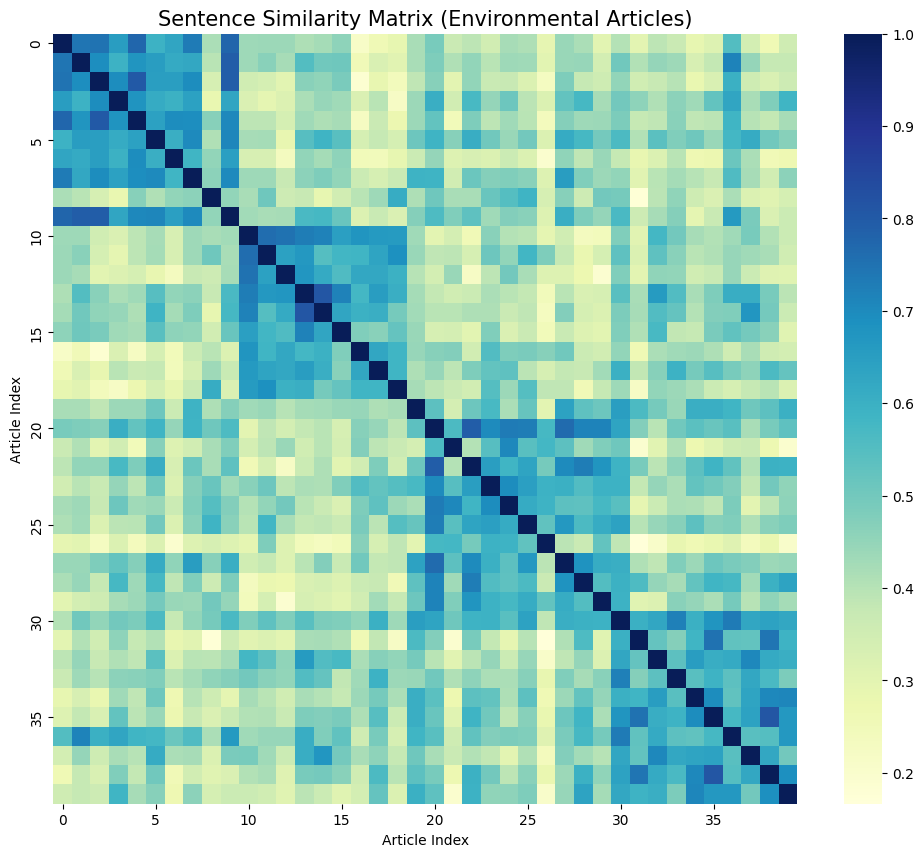

In [ ]:
# 1. 모델 로드
model = SentenceTransformer('snunlp/KR-SBERT-V40K-klueNLI-augSTS')

# 2. 문장 임베딩 생성
embeddings = model.encode(articles)

# 3. 코사인 유사도 행렬 계산
# util.cos_sim은 모든 문장 쌍 간의 유사도를 계산하여 행렬로 반환합니다.
cosine_scores = util.cos_sim(embeddings, embeddings).numpy()

# 4. 시각화 (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cosine_scores,
    annot=False,        # 데이터가 많으므로 숫자는 생략
    cmap='YlGnBu',      # 색상 테마 (노랑-초록-파랑)
    xticklabels=5,      # 5개 단위로 라벨 표시
    yticklabels=5
)

plt.title("Sentence Similarity Matrix (Environmental Articles)", fontsize=15)
plt.xlabel("Article Index")
plt.ylabel("Article Index")
plt.show()

In [ ]:
import numpy as np
from sentence_transformers import util

# 1. 비교 기준이 될 '타겟 키워드' 임베딩 생성
target_query = "기후변화 탄소중립 위기 대응" # 핵심 키워드 조합
target_embedding = model.encode(target_query)

print("-"*30)
print("Target Embedding")
print(target_embedding[0:10])
print("-"*30)

# 2. 타겟 임베딩과 모든 기사(문장) 임베딩 간의 유사도 계산
# util.cos_sim은 (1, 임베딩차원)과 (문장수, 임베딩차원)을 비교해 (1, 문장수) 결과 반환
query_distances = util.cos_sim(target_embedding, embeddings).numpy()[0]

# 3. 유사도가 가장 높은 상위 3개 인덱스 추출
top_3_indices = np.argsort(query_distances)[-3:][::-1]

# 4. 결과 출력
print(f"🎯 검색어 '{target_query}'와 가장 밀접한 핵심 문장")
print("=" * 60)

for i, idx in enumerate(top_3_indices):
    score = query_distances[idx]
    print(f"[{i+1}위] 유사도: {score:.4f}")
    print(f"문장: {articles[idx]}\n")

------------------------------
Target Embedding
[ 0.13804114  0.32720572 -0.19145304 -0.05466092  0.87001663 -0.97145826
 -0.23792395  0.0599444   0.19673568  0.06417011]
------------------------------
🎯 검색어 '기후변화 탄소중립 위기 대응'와 가장 밀접한 핵심 문장
[1위] 유사도: 0.6177
문장: 국제 기후 협약 점검 회의에서 감축 목표 상향이 논의됐다. 각국은 온실가스 감축과 탄소시장 연계, 기후 재원 확대를 함께 검토했다. 탄소중립 이행을 위한 측정·보고 체계도 강화된다.

[2위] 유사도: 0.6026
문장: 국내 평균 기온 상승이 지속되며 기후변화 영향이 뚜렷해졌다. 온실가스 감축과 탄소중립 이행이 중요 과제로 제시됐고, 재생에너지 확대와 전력망 개선이 함께 논의됐다. 전문가들은 탄소 배출 관리가 산업 경쟁력과도 연결된다고 말했다.

[3위] 유사도: 0.5926
문장: 산림 훼손이 탄소 흡수원 약화로 이어진다는 연구 결과가 발표됐다. 산림 보전과 산불 예방이 탄소중립 전략의 핵심으로 부상했으며, 온실가스 감축과 자연 기반 해법이 함께 강조된다.



In [ ]:
!pip install kiwipiepy
!pip install koreanize-matplotlib

In [ ]:
# 1. 일단 폰트 파일부터 다운로드 (가장 확실한 방법)
!apt-get install -y fonts-nanum > /dev/null

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 2. 폰트 경로 설정 및 직접 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fe = fm.FontEntry(fname=font_path, name='NanumGothic')

# 여기서 에러가 났던 부분 수정: fm.fontManager (M이 대문자여야 함)
fm.fontManager.ttflist.insert(0, fe)

# 3. 설정 적용
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

print("설정 완료! 이제 아래 코드로 확인해 보세요.")

설정 완료! 이제 아래 코드로 확인해 보세요.


In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi
from collections import Counter
from itertools import combinations

In [ ]:
articles = [
    "수도권의 초미세먼지 농도가 다시 나쁨 수준을 기록했다. 대기오염이 장기화되면서 호흡기 질환 위험이 커졌고, 배출 저감을 위한 교통 정책이 논의됐다. 전문가들은 질소산화물과 황산화물 같은 오염물질이 정체 기상과 결합해 미세먼지를 악화시킨다고 설명했다.",
    "산업단지 주변에서 대기오염 민원이 증가했다. 굴뚝 배출과 비산먼지 관리가 부족하다는 지적이 이어졌고, 지자체는 배출원 점검과 측정망 확대를 추진한다고 밝혔다. 주민들은 초미세먼지 경보가 잦아졌다며 건강 영향 평가를 요구했다.",
    "노후 경유차가 대기오염의 주요 원인으로 지목되면서 운행 제한이 확대됐다. 환경 당국은 질소산화물 배출 감소를 목표로 조기 폐차와 저공해 장치 부착을 병행할 계획이다. 시민들은 미세먼지와 대기오염 예보 정확도를 높여달라고 요청했다.",
    "겨울철 난방 수요 증가로 오염물질 배출이 늘었다. 석탄 발전 가동이 늘면서 황산화물 배출이 증가했고, 단기적으로는 대기오염 경보가 발령됐다. 정부는 배출 저감 설비 가동과 연료 전환을 함께 점검하겠다고 밝혔다.",
    "도심 교통량 증가로 질소산화물 농도가 상승했다. 대기오염 저감을 위해 버스 전용차로 확대와 대중교통 전환이 제시됐으며, 공회전 단속도 강화된다. 전문가들은 미세먼지의 2차 생성이 증가할 수 있다고 분석했다.",
    "드론 기반 감시 체계가 도입되며 배출원 추적이 정밀해졌다. 산업 현장의 배출이 확인되면 즉시 점검이 이뤄지고, 오염물질 저감 조치가 요구된다. 지자체는 초미세먼지 저감을 위해 상시 모니터링을 확대할 계획이다.",
    "학교 주변 공기질 관리가 강화된다. 실내 공기청정 설비 지원과 함께, 통학로 차량 공회전 제한이 추진된다. 학부모들은 대기오염이 심한 날에는 미세먼지 대응 지침을 명확히 공지해달라고 요구했다.",
    "국외 유입이 대기오염에 영향을 미친다는 분석이 나왔다. 위성 관측과 지상 관측을 결합해 미세먼지 예보를 개선하고, 질소산화물 이동 경로를 추적하는 연구가 진행 중이다. 국제 협력으로 오염물질 감축 논의도 확대되고 있다.",
    "도시숲 조성이 대기오염 완화에 기여한다는 평가가 나왔다. 녹지 확대는 미세먼지 저감뿐 아니라 열섬 완화에도 도움이 될 수 있다. 지자체는 대기오염 취약 지역을 중심으로 가로수와 공원 확충 계획을 공개했다.",
    "대기오염 경보 일수가 늘면서 시민 불편이 커졌다. 전문가들은 배출 관리와 함께 생활 속 저감 행동이 필요하다고 강조했다. 정부는 초미세먼지, 질소산화물, 황산화물 관리 기준을 단계적으로 강화하는 방안을 검토 중이다.",
    "하천 수질이 개선됐다는 평가가 나왔지만, 집중호우 때 비점오염원이 유입돼 수질 악화가 반복될 수 있다는 지적이 제기됐다. 관계 기관은 하수 처리 시설 고도화와 오염원 관리를 병행하며 수질 모니터링을 강화할 계획이다.",
    "농업 지역에서 비점오염원 관리가 핵심 과제로 떠올랐다. 비료와 토양이 유출되면 하천 수질과 호소 수질이 악화될 수 있다. 지자체는 완충녹지 조성과 친환경 농법 지원으로 비점오염원을 줄이겠다고 밝혔다.",
    "지하수 고갈 문제가 심화되며 지하수 관리 정책이 개편된다. 강수 패턴 변화로 지하수 재충전이 줄었다는 분석이 나왔고, 무분별한 취수로 지하수 수위가 하락했다. 전문가들은 수질과 수량을 함께 보는 통합 관리가 필요하다고 강조했다.",
    "상수원 보호구역 단속이 강화된다. 불법 시설이 발견되면 즉시 조치가 이뤄지고, 취수원 오염 가능성을 낮추기 위한 관리가 확대된다. 주민들은 수돗물 수질 신뢰를 높이기 위해 정수 과정 공개와 수질 데이터 공개를 요구했다.",
    "수돗물 신뢰 회복을 위해 정수 처리 공정 점검이 강화됐다. 취수원부터 정수장까지 단계별 위험 요인을 재평가하고, 이상 징후를 조기에 감지하는 센서 기반 수질 모니터링을 확대할 계획이다. 수돗물 수질 기준도 재점검된다.",
    "산업 폐수 무단 방류가 적발되며 하천 수질이 악화될 우려가 커졌다. 당국은 과징금과 조업정지 등 강력한 처분을 예고했다. 시민단체는 폐수 관리 강화와 수질 감시 체계 상시화를 요구했다.",
    "댐 수위 관리가 기후 변화에 맞춰 조정된다. 가뭄과 홍수에 대비해 방류량을 최적화하는 운영 체계가 검토되고 있으며, 수자원 확보와 하천 수질 관리가 함께 고려된다. 전문가들은 예측 모델 기반 운영이 중요하다고 밝혔다.",
    "물 재이용 정책이 확대되면서 중수도 시스템 도입이 늘고 있다. 공공시설에서 재이용수를 사용하면 물 부족 완화와 수자원 효율 개선에 도움이 된다. 지자체는 수질 기준을 충족하는 재이용수 확대를 추진한다.",
    "습지 복원 사업이 확대된다. 습지는 오염물질을 자연 정화해 하천 수질 개선에 기여하고, 홍수 완충 역할도 한다. 환경 단체는 습지 보전이 수질 관리와 생태계 보전에 모두 필요하다고 강조했다.",
    "해양 플라스틱 오염이 연안 생태계에 위협이 되고 있다. 해양 쓰레기 수거와 재활용 체계가 논의되며, 해양 수질과 생태 영향 평가도 진행된다. 국제 협력을 통해 해양 플라스틱 감축 목표를 조정한다.",

    "국내 평균 기온 상승이 지속되며 기후변화 영향이 뚜렷해졌다. 온실가스 감축과 탄소중립 이행이 중요 과제로 제시됐고, 재생에너지 확대와 전력망 개선이 함께 논의됐다. 전문가들은 탄소 배출 관리가 산업 경쟁력과도 연결된다고 말했다.",
    "폭염과 한파 같은 극단적 기후가 잦아지면서 기후변화 적응 정책이 강화된다. 지자체는 폭염 취약계층 보호와 재난 대응 체계를 점검하고, 에너지 수요 관리도 병행한다. 기후 리스크가 도시 정책에 반영된다.",
    "탄소중립 목표 달성을 위한 산업 전환이 가속화되고 있다. 기업들은 온실가스 감축을 위해 공정 효율 개선과 전기화 투자를 확대하며, 재생에너지 구매도 늘리고 있다. 탄소 배출 저감이 핵심 지표로 자리 잡았다.",
    "해수면 상승으로 연안 침수 위험이 증가했다. 기후변화로 해안 재해가 늘 수 있어 방재 인프라 확충이 추진된다. 전문가들은 탄소중립 추진과 함께 기후변화 적응 투자도 확대해야 한다고 강조했다.",
    "도시 열섬 현상이 심화되며 폭염 피해가 늘고 있다. 녹지 확대와 쿨루프 도입이 추진되고, 건물 에너지 효율 개선도 병행된다. 기후변화로 인한 온도 상승이 장기적으로 에너지 부담을 키울 수 있다는 분석이 나온다.",
    "산림 훼손이 탄소 흡수원 약화로 이어진다는 연구 결과가 발표됐다. 산림 보전과 산불 예방이 탄소중립 전략의 핵심으로 부상했으며, 온실가스 감축과 자연 기반 해법이 함께 강조된다.",
    "기후변화로 농작물 생산 변동성이 확대되고 있다. 가뭄과 고온이 수확량에 영향을 주며, 병해충 발생 시기도 변하고 있다. 전문가들은 적응형 품종 개발과 재생에너지 기반 스마트농업이 필요하다고 밝혔다.",
    "국제 기후 협약 점검 회의에서 감축 목표 상향이 논의됐다. 각국은 온실가스 감축과 탄소시장 연계, 기후 재원 확대를 함께 검토했다. 탄소중립 이행을 위한 측정·보고 체계도 강화된다.",
    "탄소 배출권 거래가 확대되며 기업의 배출 관리가 중요해졌다. 배출량 산정과 감축 프로젝트 투자, 재생에너지 전환이 동시에 추진된다. 시장 참여자들은 탄소 가격 변동성이 리스크라고 평가했다.",
    "청소년 대상 기후변화 교육이 확대된다. 탄소중립 실천과 에너지 절약, 이동수단 전환 캠페인이 진행되며 지역사회 참여가 늘고 있다. 전문가들은 교육이 온실가스 감축 행동으로 이어져야 한다고 말했다.",

    "생활 폐기물 발생량이 증가하며 폐기물 관리 부담이 커졌다. 지자체는 분리배출 홍보를 강화하고 재활용 체계를 개선하겠다고 밝혔다. 일회용품 감량 정책도 함께 추진되며, 자원순환 목표가 상향 조정됐다.",
    "플라스틱 재활용률을 높이기 위한 제도 개선이 추진된다. 단일 소재 포장 확대와 라벨 제거 의무가 논의됐고, 생산자책임제 강화로 재활용 원료 사용을 늘리는 방안이 검토된다. 재활용 시장 안정화가 과제로 꼽힌다.",
    "건설 폐기물 불법 매립이 적발됐다. 토양 오염과 지하수 오염 우려가 제기되며, 폐기물 처리 이력 관리가 강화된다. 관계 기관은 불법 처리 단속과 함께 합법 처리 인프라 확충이 필요하다고 밝혔다.",
    "음식물 쓰레기 감량 정책이 확대된다. 계량 기반 요금제가 개선되고, 음식물 쓰레기 수거와 악취 관리가 강화된다. 일부 지역은 음식물 쓰레기 자원화 시설을 확충해 자원순환을 높이겠다고 밝혔다.",
    "전자 폐기물 처리 시설이 확충된다. 희귀 금속 회수와 재활용 기술 개발이 병행되며, 순환자원 확보가 기대된다. 전문가들은 전자 폐기물의 안전한 수거망과 분리배출 가이드가 중요하다고 강조했다.",
    "자원순환 경제 활성화를 위한 법 개정이 추진된다. 재사용 제품 품질 기준을 마련하고, 재활용 원료 시장을 키우는 정책이 포함됐다. 기업들은 폐기물 감량과 재활용 의무 이행을 위해 공급망을 재정비하고 있다.",
    "소각 시설 증설을 두고 주민 반발이 이어졌다. 주민들은 대기오염과 건강 영향을 우려하며 정보 공개를 요구했다. 지자체는 배출 기준 강화와 주민 참여 모니터링을 제안하며 폐기물 감량 정책 병행을 강조했다.",
    "의료 폐기물 관리 기준이 강화된다. 감염 위험 차단을 위해 수거·운반·보관 단계별 기준이 정비되고, 처리 시설 안전 점검이 확대된다. 의료 폐기물 분리배출 교육도 강화된다.",
    "재사용 가능한 포장재 도입이 확대된다. 기업들은 회수·세척·재공급 시스템을 구축하고, 소비자 참여 인센티브도 검토한다. 재사용과 재활용을 동시에 확대해 폐기물 발생을 줄이겠다는 목표다.",
    "폐기물 에너지화 시설이 주목받고 있다. 매립을 줄이고 에너지를 회수해 온실가스 감축에 기여할 수 있다는 기대가 나온다. 다만 폐기물 소각 과정의 배출 관리와 경제성 검증이 과제로 제기됐다."
]

선정된 중요 키워드: ['확대', '오염', '관리', '배출', '수질', '강화', '폐기물', '대기', '기후', '탄소']


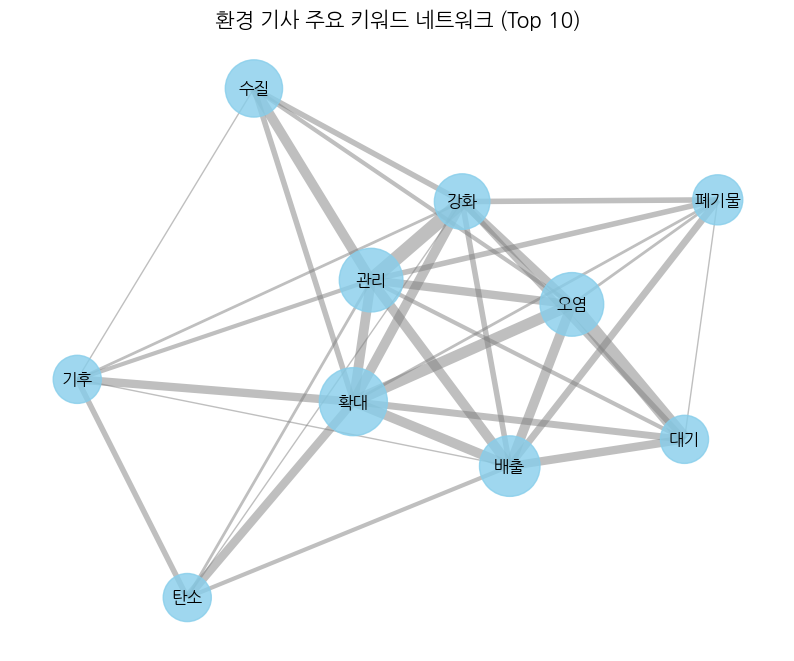

In [ ]:
# 1. 데이터 로드 및 Kiwi 초기화
kiwi = Kiwi()

# 2. 형태소 분석 및 명사 추출 함수
def get_nouns(text):
    # 명사(NNG, NNP)만 추출, 2글자 이상인 단어만 선택
    result = kiwi.analyze(text)
    nouns = [token.form for token in result[0][0] if token.tag in ['NNG', 'NNP'] and len(token.form) > 1]
    return nouns

# 전체 문서에서 명사 리스트 추출
docs_nouns = [get_nouns(article) for article in articles]

# 3. 중요 키워드 10개 선정 (빈도수 기준)
all_nouns = [noun for doc in docs_nouns for noun in doc]
top_10_keywords = [item[0] for item in Counter(all_nouns).most_common(10)]

print(f"선정된 중요 키워드: {top_10_keywords}")

# 4. 공출현(Co-occurrence) 매트릭스 생성
# 선정된 10개 키워드 간의 관계만 계산
word_pairs = Counter()

for tokens in docs_nouns:
    # 각 문서에서 top 10 키워드에 속하는 단어들만 필터링
    target_words = [w for w in tokens if w in top_10_keywords]
    # 한 문서 내에서 등장한 단어들의 조합(Pair) 생성 (중복 제거 후)
    target_words = list(set(target_words))
    for pair in combinations(sorted(target_words), 2):
        word_pairs[pair] += 1

# 5. NetworkX 그래프 생성
G = nx.Graph()

# 노드 추가
for word in top_10_keywords:
    G.add_node(word, count=all_nouns.count(word))

# 엣지(연결선) 추가 (빈도수를 가중치로 사용)
for (w1, w2), weight in word_pairs.items():
    if weight > 0:
        G.add_edge(w1, w2, weight=weight)

# 6. 시각화
# 한글 폰트 설정 (Windows: Malgun Gothic, Mac: AppleGothic)
plt.rcParams['font.family'] = 'NanumGothic' # 환경에 맞춰 변경하세요
plt.figure(figsize=(10, 8))

# 레이아웃 설정
pos = nx.spring_layout(G, k=0.5, seed=42)

# 노드 크기를 빈도수에 비례하게 설정
node_sizes = [G.nodes[node]['count'] * 100 for node in G.nodes()]

# 연결선 두께를 공출현 빈도에 비례하게 설정
edges = G.edges()
weights = [G[u][v]['weight'] for u, v in edges]

# 그래프 그리기
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color='skyblue', alpha=0.8)
nx.draw_networkx_edges(G, pos, width=weights, edge_color='gray', alpha=0.5)
nx.draw_networkx_labels(G, pos, font_size=12, font_family='NanumGothic')
#nx.draw_networkx_labels(G, pos, font_size=12)

plt.title("환경 기사 주요 키워드 네트워크 (Top 10)", size=15)
plt.axis('off')
plt.show()